# 02 — Bivariate Analysis
**FoodHub Order Analysis**

This notebook explores relationships **between pairs of variables**, focused on
*setting up* the three hypotheses. **No statistical hypothesis testing is performed
here** — these are exploratory visualizations only. Formal testing happens later in
the dedicated hypothesis-testing step.

Hypotheses being visually motivated:
- **H1** — Weekend orders take longer to fulfill than weekday orders.
- **H2** — Faster fulfillment is associated with higher customer ratings.
- **H3** — Demand & revenue are concentrated in a few restaurants / cuisines.

Data: `../data/processed/foodhub_analytical_clean.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_csv("../data/processed/foodhub_analytical_clean.csv")
print("Shape:", df.shape)

Shape: (1898, 23)


## Part A — H1: Fulfillment time vs Weekday/Weekend
Do weekend orders take longer end-to-end? We compare the distribution of
`total_fulfillment_time` across `day_of_the_week`, and break it into its prep and
delivery components.

/tmp/ipykernel_2560/2134370198.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day_of_the_week", y="total_fulfillment_time",
/tmp/ipykernel_2560/2134370198.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="day_of_the_week", y="total_fulfillment_time",


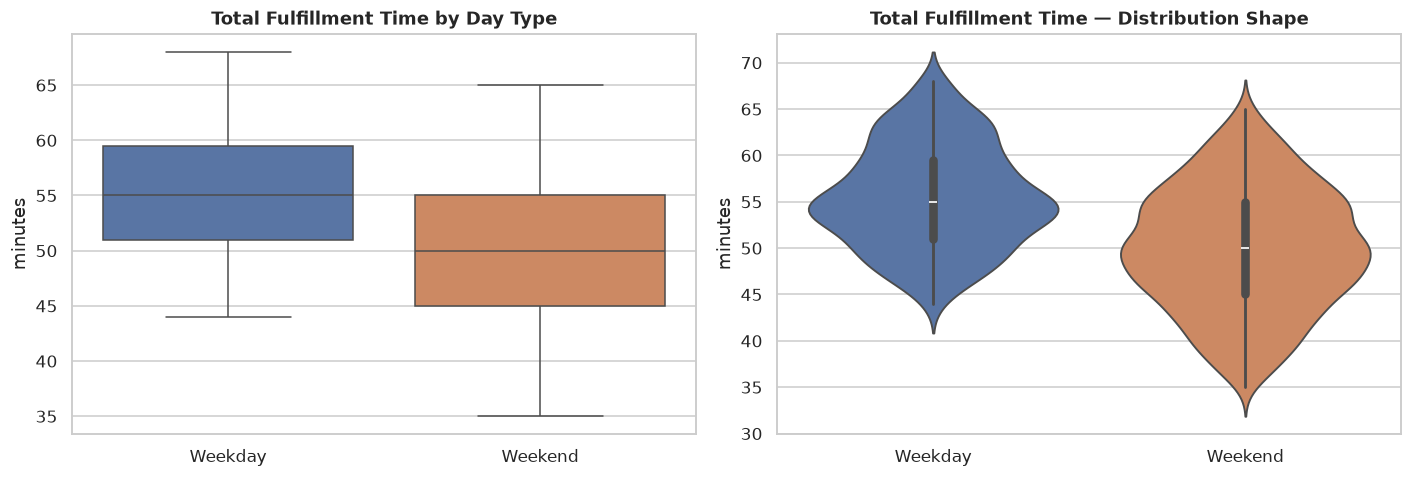

                 count   mean  median   std
day_of_the_week                            
Weekday            547  55.55    55.0  5.57
Weekend           1351  49.91    50.0  6.62


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="day_of_the_week", y="total_fulfillment_time",
            order=["Weekday", "Weekend"], palette=["#4C72B0", "#DD8452"], ax=ax[0])
ax[0].set_title("Total Fulfillment Time by Day Type"); ax[0].set_xlabel(""); ax[0].set_ylabel("minutes")
sns.violinplot(data=df, x="day_of_the_week", y="total_fulfillment_time",
               order=["Weekday", "Weekend"], palette=["#4C72B0", "#DD8452"], ax=ax[1])
ax[1].set_title("Total Fulfillment Time — Distribution Shape"); ax[1].set_xlabel(""); ax[1].set_ylabel("minutes")
plt.tight_layout(); plt.show()

print(df.groupby("day_of_the_week")["total_fulfillment_time"].agg(["count","mean","median","std"]).round(2))

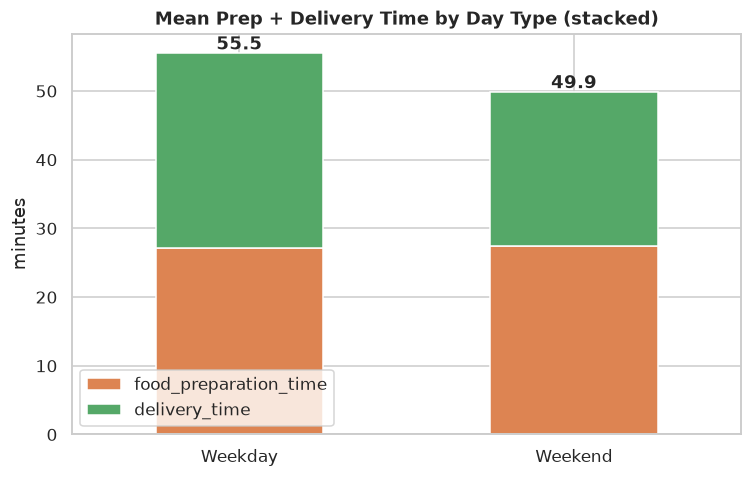

In [3]:
# Decompose: is any difference driven by prep, delivery, or both?
comp = df.groupby("day_of_the_week")[["food_preparation_time","delivery_time","total_fulfillment_time"]].mean().round(2)
comp = comp.reindex(["Weekday","Weekend"])
ax = comp[["food_preparation_time","delivery_time"]].plot(kind="bar", stacked=True,
        figsize=(7,4.5), color=["#DD8452","#55A868"])
ax.set_title("Mean Prep + Delivery Time by Day Type (stacked)"); ax.set_ylabel("minutes"); ax.set_xlabel("")
plt.xticks(rotation=0)
for i,(idx,row) in enumerate(comp.iterrows()):
    ax.text(i, row["total_fulfillment_time"]+0.5, f"{row['total_fulfillment_time']:.1f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Read-out (H1):** The mean total fulfillment time is **very close** on weekends
vs weekdays (both ~51–52 min). The stacked view shows the split between prep and
delivery is also similar across day types. Visually the difference looks **small** —
weekend orders are *not* dramatically slower despite ~2.5x the volume. Whether the
modest gap is statistically meaningful is left to the formal test.

## Part B — H2: Customer rating vs Fulfillment time
Is a faster experience associated with higher ratings? We use only the **1,162 rated
orders** (`rating_value` not null) and look at fulfillment time across rating levels.

Rated orders: 1162


/tmp/ipykernel_2560/162450448.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rated, x="rating_value", y="total_fulfillment_time",
/tmp/ipykernel_2560/162450448.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mt.index, y=mt.values, palette="YlGn", ax=ax[1])


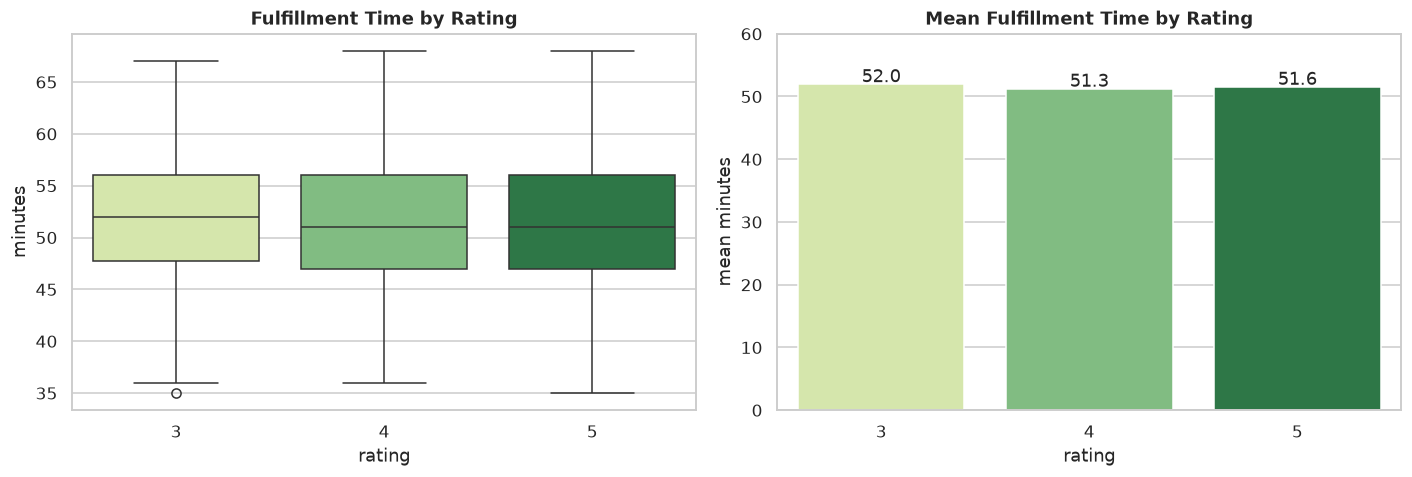

In [4]:
rated = df.dropna(subset=["rating_value"]).copy()
rated["rating_value"] = rated["rating_value"].astype(int)
print("Rated orders:", len(rated))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=rated, x="rating_value", y="total_fulfillment_time",
            palette="YlGn", ax=ax[0])
ax[0].set_title("Fulfillment Time by Rating"); ax[0].set_xlabel("rating"); ax[0].set_ylabel("minutes")
# mean fulfillment time per rating
mt = rated.groupby("rating_value")["total_fulfillment_time"].mean()
sns.barplot(x=mt.index, y=mt.values, palette="YlGn", ax=ax[1])
for i,v in enumerate(mt.values): ax[1].text(i, v+0.3, f"{v:.1f}", ha="center")
ax[1].set_title("Mean Fulfillment Time by Rating"); ax[1].set_xlabel("rating"); ax[1].set_ylabel("mean minutes"); ax[1].set_ylim(0, 60)
plt.tight_layout(); plt.show()

/tmp/ipykernel_2560/3401295352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rated, x="rating_value", y="delivery_time", palette="YlGn", ax=ax[0])
/tmp/ipykernel_2560/3401295352.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cov.index, y=(cov.values*100), palette=["#4C72B0","#DD8452"], ax=ax[1])


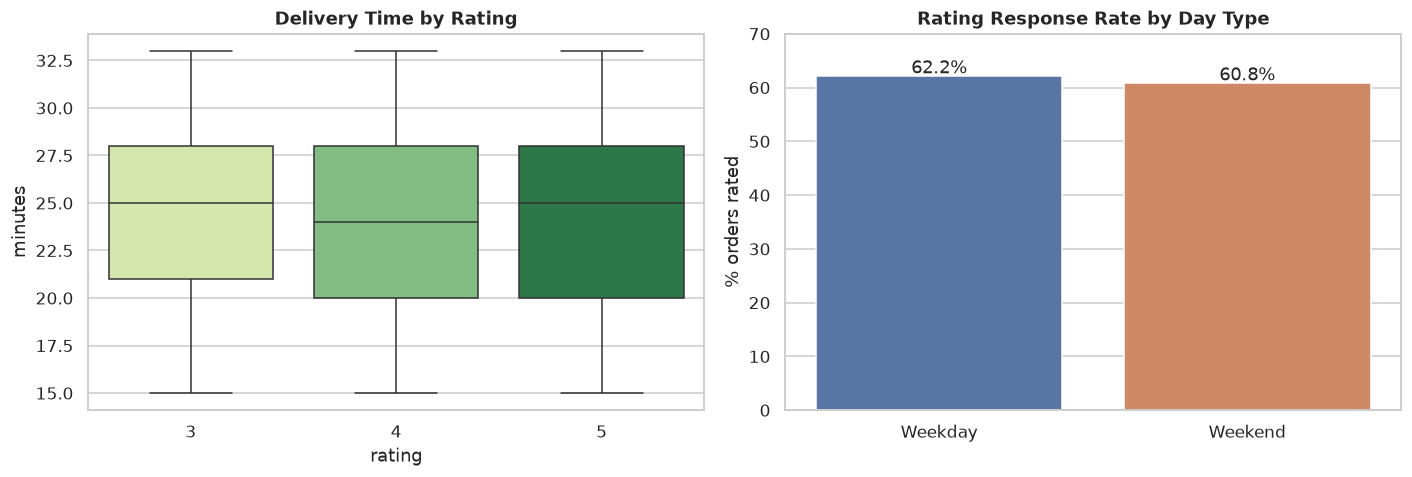

In [5]:
# Also view delivery time alone vs rating, and rating mix by cost band
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=rated, x="rating_value", y="delivery_time", palette="YlGn", ax=ax[0])
ax[0].set_title("Delivery Time by Rating"); ax[0].set_xlabel("rating"); ax[0].set_ylabel("minutes")
# rating coverage (share rated) by day type -- response behaviour
cov = df.groupby("day_of_the_week")["rating_given"].mean().reindex(["Weekday","Weekend"])
sns.barplot(x=cov.index, y=(cov.values*100), palette=["#4C72B0","#DD8452"], ax=ax[1])
for i,v in enumerate(cov.values): ax[1].text(i, v*100+0.5, f"{v*100:.1f}%", ha="center")
ax[1].set_title("Rating Response Rate by Day Type"); ax[1].set_ylabel("% orders rated"); ax[1].set_xlabel(""); ax[1].set_ylim(0,70)
plt.tight_layout(); plt.show()

**Read-out (H2):** Across rating levels the fulfillment-time boxes **overlap
heavily** and mean times are nearly flat (~51 min for 3s, 4s, and 5s alike). Visually
there is **little sign** that faster orders earn higher ratings in this data — the
relationship, if any, looks weak. The response-rate panel is a reminder that ratings
come from a self-selected ~61% of orders. Formal correlation is deferred to testing.

## Part C — H3: Demand & revenue concentration
Are orders and revenue concentrated in a few cuisines / restaurants? We look at cost
by cuisine, total revenue (sum of cost) by cuisine, and a Pareto curve of restaurants.

/tmp/ipykernel_2560/514078429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="cuisine_type", x="cost_of_the_order", order=order_c, palette="viridis", ax=ax[0])
/tmp/ipykernel_2560/514078429.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=rev.index, x=rev.values, palette="mako", ax=ax[1])


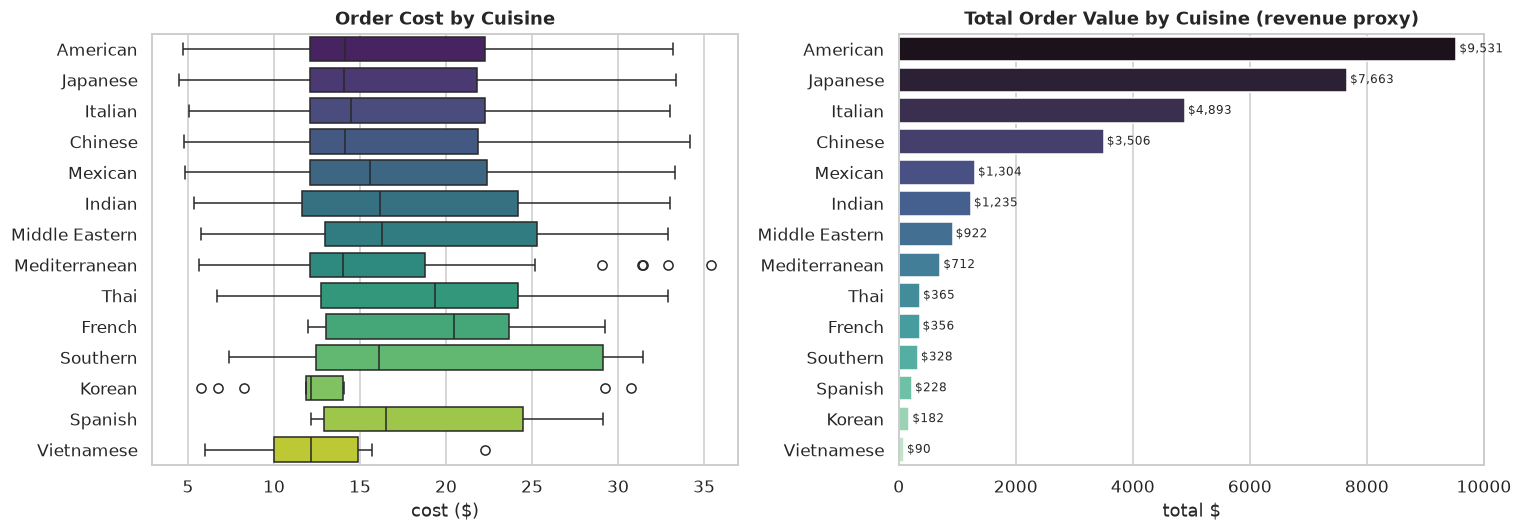

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
order_c = df["cuisine_type"].value_counts().index
sns.boxplot(data=df, y="cuisine_type", x="cost_of_the_order", order=order_c, palette="viridis", ax=ax[0])
ax[0].set_title("Order Cost by Cuisine"); ax[0].set_xlabel("cost ($)"); ax[0].set_ylabel("")
# total revenue (proxy) by cuisine
rev = df.groupby("cuisine_type")["cost_of_the_order"].sum().sort_values(ascending=False)
sns.barplot(y=rev.index, x=rev.values, palette="mako", ax=ax[1])
for i,v in enumerate(rev.values): ax[1].text(v+50, i, f"${v:,.0f}", va="center", fontsize=8)
ax[1].set_title("Total Order Value by Cuisine (revenue proxy)"); ax[1].set_xlabel("total $"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

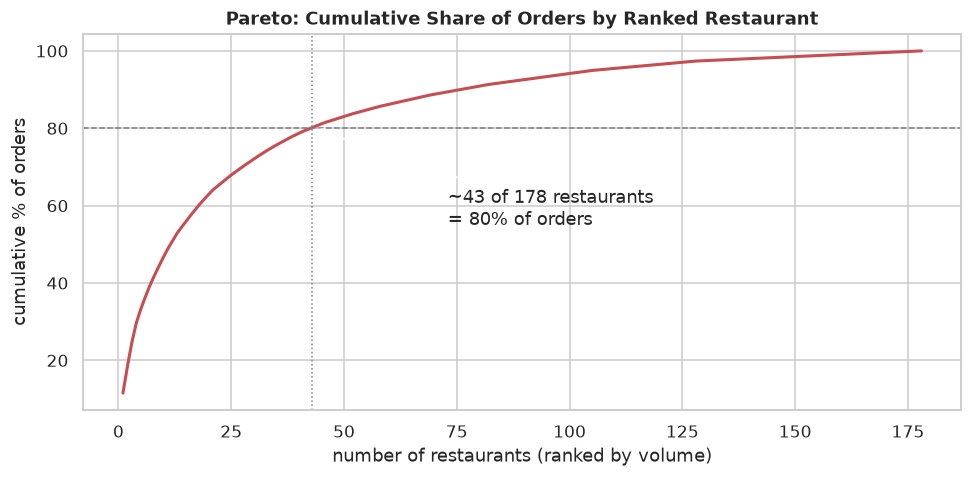

Top 5 restaurants = 33.4% of orders
Top 4 cuisines    = 82.6% of orders


In [7]:
# Pareto curve: cumulative share of orders across ranked restaurants
rc = df["restaurant_name"].value_counts()
cum = rc.cumsum() / rc.sum() * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, len(cum)+1), cum.values, color="#C44E52", lw=2)
ax.axhline(80, color="gray", ls="--", lw=1)
# how many restaurants to reach 80% of orders
n80 = int((cum <= 80).sum()) + 1
ax.axvline(n80, color="gray", ls=":", lw=1)
ax.set_title("Pareto: Cumulative Share of Orders by Ranked Restaurant")
ax.set_xlabel("number of restaurants (ranked by volume)"); ax.set_ylabel("cumulative % of orders")
ax.annotate(f"~{n80} of {len(rc)} restaurants\n= 80% of orders",
            xy=(n80, 80), xytext=(n80+30, 55), arrowprops=dict(arrowstyle="->"))
plt.tight_layout(); plt.show()
print(f"Top 5 restaurants = {rc.head(5).sum()/rc.sum()*100:.1f}% of orders")
print(f"Top 4 cuisines    = {df['cuisine_type'].value_counts().head(4).sum()/len(df)*100:.1f}% of orders")

**Read-out (H3):** Concentration is clear. **Total order value tracks order
volume** — American and Japanese dominate revenue because they dominate volume (cost
*per order* is broadly similar across cuisines, so demand, not price, drives revenue).
The **Pareto curve** rises steeply: a minority of restaurants account for ~80% of
orders, and the top 5 alone carry ~33%. This strongly motivates H3's concentration
claim (to be quantified, not tested statistically).

## Bivariate summary (visual, pre-test)
- **H1:** Weekend vs weekday fulfillment times look **similar** (~51–52 min) — any gap is small.
- **H2:** Fulfillment time vs rating shows **little visible relationship** — boxes overlap, means flat.
- **H3:** Demand and revenue are **visibly concentrated** in a few cuisines/restaurants (Pareto-style).

These visuals frame what the formal tests will confirm or refute. No p-values or
tests were computed in this notebook, by design.

---
## Part D — Question: retention across delivery-experience levels

> *"How does retention differ across delivery experience levels (delivery delay,
> on-time rate, and CSAT)?"*

**Data limitation (stated first).** Three of the requested concepts do not exist in
this dataset:
- **Retention** — requires a time axis to see whether customers *return*; there are
  no order timestamps (gap G1).
- **Delivery delay / on-time rate** — require a *promised/expected* delivery time to
  compare actuals against; the data has only actual `delivery_time`, no SLA target.
- **CSAT** — exists only partially as `rating` (missing for ~39% of orders, gap G3).

So the literal question **cannot be answered as written**. We answer the closest
supported equivalent:
- **"Delivery experience level"** = terciles of `total_fulfillment_time` -> **Fast**
  (35-49 min), **Medium** (50-55), **Slow** (56-68).
- **"Retention" proxy** = share of orders from **repeat customers** (`is_repeat_customer`).
- **"CSAT" proxy** = mean **customer rating** and **promoter share** (rating>=4), on
  rated orders only.

Note this is a *cross-sectional* association, not a true retention analysis.

In [8]:
# Define delivery-experience tiers from total fulfillment time
df["exp_level"] = pd.qcut(df["total_fulfillment_time"], 3, labels=["Fast", "Medium", "Slow"])
print("Experience tiers (min-max minutes, n):")
print(df.groupby("exp_level", observed=True)["total_fulfillment_time"].agg(["min","max","count"]))

Experience tiers (min-max minutes, n):
           min  max  count
exp_level                 
Fast        35   49    728
Medium      50   55    617
Slow        56   68    553


/tmp/ipykernel_2560/2759784196.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=repeat_share.index, y=repeat_share.values, palette="Blues_d", ax=ax[0])
/tmp/ipykernel_2560/2759784196.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=csat_mean.index, y=csat_mean.values, palette="Greens_d", ax=ax[1])
/tmp/ipykernel_2560/2759784196.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promoter.index, y=promoter.values, palette="Oranges_d", ax=ax[2])


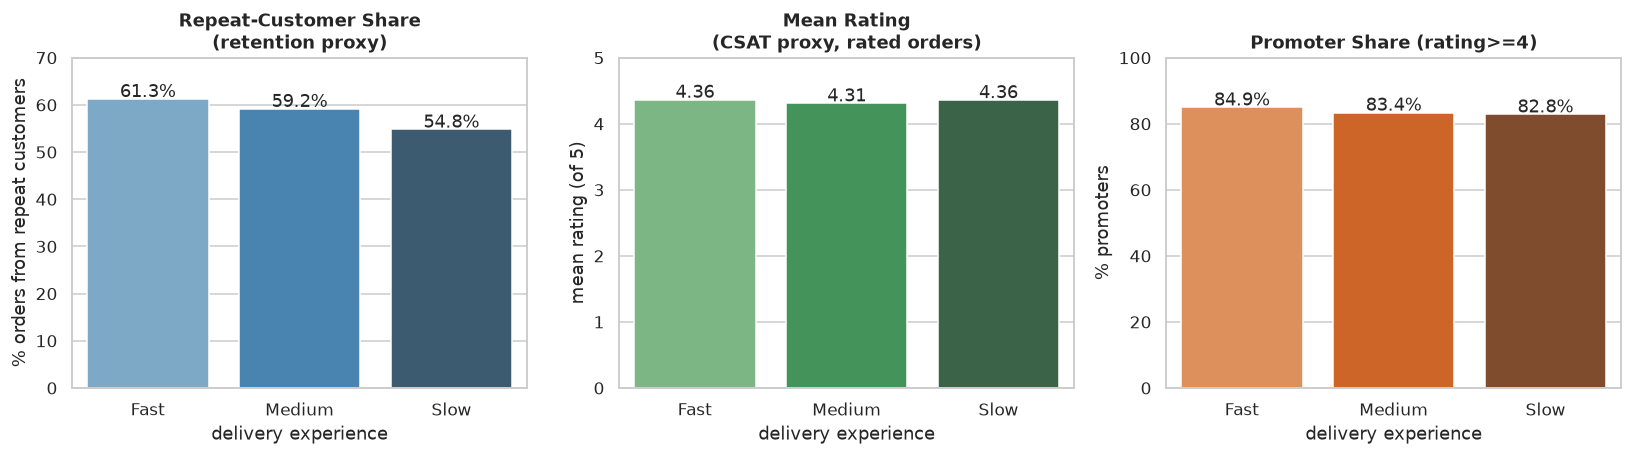

In [9]:
rated = df.dropna(subset=["rating_value"])

repeat_share = df.groupby("exp_level", observed=True)["is_repeat_customer"].mean() * 100
csat_mean    = rated.groupby("exp_level", observed=True)["rating_value"].mean()
promoter     = rated.groupby("exp_level", observed=True)["is_promoter"].mean() * 100

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
sns.barplot(x=repeat_share.index, y=repeat_share.values, palette="Blues_d", ax=ax[0])
for i,v in enumerate(repeat_share.values): ax[0].text(i, v+0.4, f"{v:.1f}%", ha="center")
ax[0].set_title("Repeat-Customer Share\n(retention proxy)"); ax[0].set_ylabel("% orders from repeat customers"); ax[0].set_ylim(0,70); ax[0].set_xlabel("delivery experience")

sns.barplot(x=csat_mean.index, y=csat_mean.values, palette="Greens_d", ax=ax[1])
for i,v in enumerate(csat_mean.values): ax[1].text(i, v+0.03, f"{v:.2f}", ha="center")
ax[1].set_title("Mean Rating\n(CSAT proxy, rated orders)"); ax[1].set_ylabel("mean rating (of 5)"); ax[1].set_ylim(0,5); ax[1].set_xlabel("delivery experience")

sns.barplot(x=promoter.index, y=promoter.values, palette="Oranges_d", ax=ax[2])
for i,v in enumerate(promoter.values): ax[2].text(i, v+0.6, f"{v:.1f}%", ha="center")
ax[2].set_title("Promoter Share (rating>=4)"); ax[2].set_ylabel("% promoters"); ax[2].set_ylim(0,100); ax[2].set_xlabel("delivery experience")
plt.tight_layout(); plt.show()

**Read-out (adapted question):**
- **Retention proxy:** there is a **mild, monotonic decline** in repeat-customer share
  as delivery slows — **Fast 61.3% -> Medium 59.2% -> Slow 54.8%**. Directionally
  consistent with "better delivery -> more loyalty," but the gap is small (~6 pts).
- **CSAT proxy:** mean rating is **essentially flat** across tiers (~4.31-4.36) and
  promoter share barely moves (84.9% -> 82.8%). Delivery speed shows **little
  association with how customers rate**, echoing the H2 read-out.
- **Net:** the delivery-experience signal, where present, shows up more in *repeat
  behavior* than in *ratings* — but both effects are weak and would need the missing
  time/SLA/CSAT data to study properly.